In [205]:
#파이썬을 이용한 K-평균 클러스터링
from sklearn.cluster import KMeans #K평균 모듈 호출
from sklearn.metrics import silhouette_samples #실루엣 모듈 호출
import matplotlib.pyplot as plt #데이터 시각화를 위한 모듈 호출

import numpy as np #데이터 핸들링을 위한 모듈 호출
import pandas as pd #데이터 핸들링을 위한 모듈 호출
from urllib import request # 이미지를 가져오기 위한 모듈 호출
from PIL import Image #이미지를 열기 위한 모듈 호출

import cv2

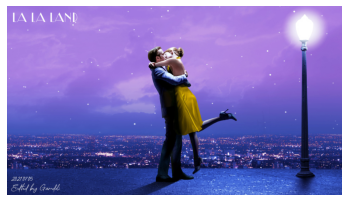

In [207]:
url ="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FvKhrJ%2Fbtq8TwX5Tni%2F7VytSB2z9ZwsiKOfhdxep0%2Fimg.jpg" #url 문자열 저장

urllib.request.urlretrieve(url,'lalaLand.jpg') #url을 통해 이미지 데이터 불러오기

img = cv2.imread('lalaLand.jpg') #불러운 이미지 데이터 읽기

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #이미지 색을 BGR에서 RGB로 변환
plt.axis('off')
plt.imshow(img) #이미지 출력


In [208]:
from skimage.transform import resize
img = resize(img,(200,200))

#8a6dd3


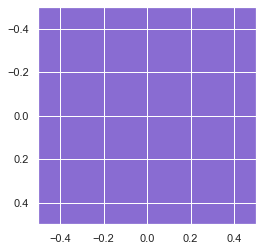

#5b4e8a


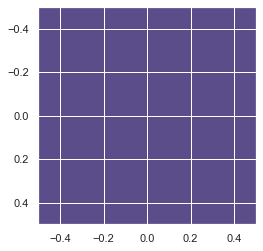

#5d60c7


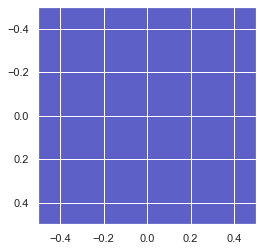

#aa82e0


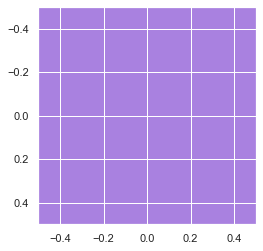

#0b0c14


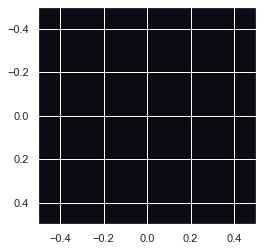

#e2d9f1


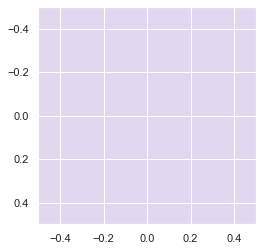

#8f7106


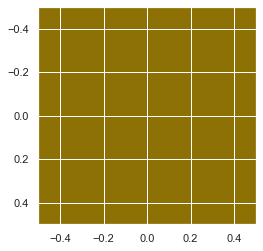

#3f51b5


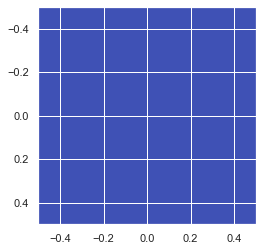

#1c2461


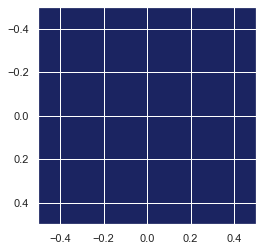

#2d3889


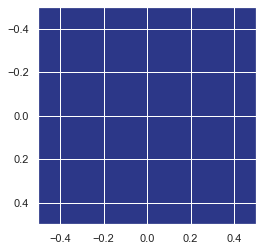

In [213]:
from matplotlib.colors import to_hex

data = pd.DataFrame(img.reshape(-1,3),columns = ['R','G','B']) #KMeans 모듈에 입력할 데이터 셋 만들기

palette_list = []


km_v = KMeans(n_clusters = 10, random_state = 0) # K값을 1~10까지 바꿔가며 최적의 값 탐색
data['Cluster'] = km_v.fit_predict(data)
palette = km_v.cluster_centers_

for color in palette:
    palette_list.append([[tuple(color)]])

 
#색 코드 및 
for color in palette_list:
    print(to_hex(color[0][0]))
    #plt.axis('off')
    plt.figure()
    
    plt.imshow(color)
    plt.show()
    


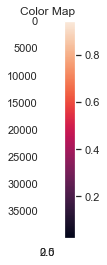

"\nimage = image.reshape(200,200,3)\nimage = resize(image,(800,1200))\n\nplt.axis('off')\nplt.imshow(image)\nplt.show()"

In [204]:
from skimage.transform import resize
data['R_cluster'] = data['Cluster'].apply(lambda x: palette_list[x][0][0][0])
data['G_cluster'] = data['Cluster'].apply(lambda x: palette_list[x][0][0][1])
data['B_cluster'] = data['Cluster'].apply(lambda x: palette_list[x][0][0][2])

image = data[['R_cluster','G_cluster','B_cluster']].values

plt.imshow(image)
plt.colorbar()

plt.title('Color Map')
plt.show()
"""
image = image.reshape(200,200,3)
image = resize(image,(800,1200))

plt.axis('off')
plt.imshow(image)
plt.show()"""